In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, RandomizedSearchCV

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

plt.rcParams['figure.figsize'] = (8, 4)
pd.set_option('display.max_colwidth', 200)


## 1. Configuración

In [2]:
DATA_DIR = Path('.')
TRAIN_PATH = DATA_DIR / 'Train.csv'
VALID_PATH = DATA_DIR / 'validation.csv'
OUTPUT_PATH = DATA_DIR / 'predicciones_modelo_interpretable.csv'

TARGET = 'pct_perdida'
ID_COL = 'parcel_id'
RANDOM_STATE = 42
N_ITER_SEARCH = 10

PESO_RENDIMIENTO = 0.60
PESO_INTERPRETABILIDAD = 0.40

print(TRAIN_PATH.exists(), VALID_PATH.exists())


True True


## 2. Carga de datos

In [3]:
train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VALID_PATH, sep=';')

X = train.drop(columns=[TARGET])
y = train[TARGET].copy()

X_model = X.drop(columns=[ID_COL], errors='ignore')
X_validation_model = validation.drop(columns=[ID_COL], errors='ignore')

numeric_features = X_model.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_model.select_dtypes(exclude=[np.number]).columns.tolist()

display(train.head())
print('Numéricas:', numeric_features)
print('Categóricas:', categorical_features)


,parcel_id,zona_provincia,tipo_olivar,riego,superficie_ha,variedad,estado_fenologico,tipo_suelo,drenaje,pendiente_%,...,rain_7d_mm,temp_media_7d,humedad_suelo_%,profundidad_suelo_cm,materia_organica_%,rendimiento_esperado_kg_ha,precio_mercado_eur_kg,coste_variable_ha,duracion_encharcamiento_dias,pct_perdida
0,OLV_42_0000,Córdoba,Tradicional,Secano,41.54,Picual,Reposo,Arcilloso,Moderado,1.5,...,186.5,17.4,82.0,64,2.84,5605,0.89,961,2.75,0.0000
1,OLV_42_0001,Jaén,Intensivo,Riego,32.67,Picual,Reposo,Franco,Malo,3.7,...,229.3,13.1,71.0,90,1.08,10571,0.83,1580,4.57,0.0262
2,OLV_42_0002,Jaén,Tradicional,Riego,3.34,Hojiblanca,Engorde,Limoso,Moderado,5.9,...,197.6,13.1,39.1,98,2.94,10030,0.81,1374,1.98,0.0000
3,OLV_42_0003,Sevilla,Intensivo,Riego,6.30,Manzanilla,Floracion,Limoso,Malo,8.5,...,142.5,13.5,67.0,55,1.38,10811,0.81,1790,2.01,0.0000
4,OLV_42_0004,Córdoba,Intensivo,Secano,34.86,Picual,Floracion,Arenoso,Moderado,0.6,...,341.9,15.8,24.0,30,0.98,6738,0.77,1152,1.40,0.0220


Numéricas: ['superficie_ha', 'pendiente_%', 'distancia_rio_m', 'altitud_m', 'rain_72h_mm', 'rain_7d_mm', 'temp_media_7d', 'humedad_suelo_%', 'profundidad_suelo_cm', 'materia_organica_%', 'rendimiento_esperado_kg_ha', 'precio_mercado_eur_kg', 'coste_variable_ha', 'duracion_encharcamiento_dias']
Categóricas: ['zona_provincia', 'tipo_olivar', 'riego', 'variedad', 'estado_fenologico', 'tipo_suelo', 'drenaje']


## 3. Selección variables según causalidad


In [4]:
variables_prioritarias = [
    'lluvia_24h_mm', 'lluvia_7d_mm', 'pendiente_pct', 'tipo_suelo',
    'capacidad_drenaje', 'humedad_suelo_pct', 'tipo_olivar',
    'rendimiento_esperado_kg_ha', 'precio_mercado_eur_kg', 'superficie_ha'
]

variables_contextuales = [
    'estado_fenologico', 'variedad', 'zona_provincia',
    'edad_olivar', 'marco_plantacion', 'densidad_olivos_ha'
]

variables_dudosas = [
    # añade aquí las que os parezcan poco defendibles
]

print('Prioritarias:', variables_prioritarias)
print('Contextuales:', variables_contextuales)
print('Dudosas:', variables_dudosas)


Prioritarias: ['lluvia_24h_mm', 'lluvia_7d_mm', 'pendiente_pct', 'tipo_suelo', 'capacidad_drenaje', 'humedad_suelo_pct', 'tipo_olivar', 'rendimiento_esperado_kg_ha', 'precio_mercado_eur_kg', 'superficie_ha']
Contextuales: ['estado_fenologico', 'variedad', 'zona_provincia', 'edad_olivar', 'marco_plantacion', 'densidad_olivos_ha']
Dudosas: []


## 4. Preprocesado

In [5]:
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])


## 5. Funciones auxiliares

In [6]:
scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def resumir_resultados_search(search, nombre_modelo):
    idx = search.best_index_
    results = pd.DataFrame(search.cv_results_)
    return {
        'modelo': nombre_modelo,
        'best_params': search.best_params_,
        'cv_mae': -results.loc[idx, 'mean_test_mae'],
        'cv_rmse': -results.loc[idx, 'mean_test_rmse'],
        'cv_r2': results.loc[idx, 'mean_test_r2']
    }

def extraer_feature_names(preprocessor, numeric_features, categorical_features):
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    return numeric_features + ohe.get_feature_names_out(categorical_features).tolist()

def col_original(feature_name, base_cols):
    for col in base_cols:
        if feature_name == col or feature_name.startswith(col + '_'):
            return col
    return feature_name

def agregar_importancias_por_variable(feature_names, importances, base_cols):
    df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    df['variable_original'] = df['feature'].apply(lambda x: col_original(x, base_cols))
    agg = df.groupby('variable_original', as_index=False)['importance'].sum().sort_values('importance', ascending=False)
    agg['importance_pct'] = 100 * agg['importance'] / agg['importance'].sum()
    return agg

def puntuar_interpretabilidad(agg_df, prioritarias, contextuales, dudosas):
    def categoria(var):
        if var in prioritarias:
            return 'prioritaria'
        if var in contextuales:
            return 'contextual'
        if var in dudosas:
            return 'dudosa'
        return 'neutra'

    pesos = {'prioritaria': 1.0, 'contextual': 0.4, 'dudosa': -0.5, 'neutra': 0.0}
    out = agg_df.copy()
    out['categoria'] = out['variable_original'].apply(categoria)
    out['peso_interpretabilidad'] = out['categoria'].map(pesos)
    out['contribucion_interpretabilidad'] = out['importance_pct'] * out['peso_interpretabilidad']
    score = out['contribucion_interpretabilidad'].sum() / 100.0
    resumen = out.groupby('categoria', as_index=False)['importance_pct'].sum().sort_values('importance_pct', ascending=False)
    return score, out, resumen

def minmax_score(series, reverse=False):
    s = series.astype(float)
    if s.max() == s.min():
        return pd.Series(np.ones(len(s)), index=s.index)
    out = (s - s.min()) / (s.max() - s.min())
    return 1 - out if reverse else out

def plot_top_variables(agg_df, title, top_n=15):
    plot_df = agg_df.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(plot_df['variable_original'], plot_df['importance_pct'])
    ax.set_title(title)
    ax.set_xlabel('% importancia agregada')
    plt.show()


## 6. Modelos y búsqueda

In [7]:
model_specs = {
    'xgboost': {
        'model': XGBRegressor(objective='reg:squarederror', random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'model__n_estimators': [200, 400, 600],
            'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
            'model__max_depth': [3, 4, 5, 6, 8],
            'model__min_child_weight': [1, 3, 5],
            'model__subsample': [0.7, 0.85, 1.0],
            'model__colsample_bytree': [0.7, 0.85, 1.0]
        }
    },
    'catboost': {
        'model': CatBoostRegressor(verbose=0, random_state=RANDOM_STATE),
        'params': {
            'model__iterations': [300, 500, 800],
            'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
            'model__depth': [4, 6, 8, 10],
            'model__l2_leaf_reg': [1, 3, 5, 7, 9]
        }
    },
    'lightgbm': {
        'model': LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'model__n_estimators': [200, 400, 600],
            'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
            'model__max_depth': [-1, 4, 6, 8],
            'model__num_leaves': [15, 31, 63, 127]
        }
    }
}


## 7. Entrenamiento, métricas e interpretabilidad

In [8]:
searches = {}
resumenes = []
resumenes_categoria = {}
base_cols = X_model.columns.tolist()

for nombre, spec in model_specs.items():
    print(f'\n===== Ajustando {nombre} =====')
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', spec['model'])])
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=spec['params'],
        n_iter=N_ITER_SEARCH,
        scoring=scoring,
        refit='mae',
        cv=cv,
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=False
    )
    search.fit(X_model, y)
    searches[nombre] = search
    resumen = resumir_resultados_search(search, nombre)

    best_pipeline = search.best_estimator_
    best_pipeline.fit(X_model, y)
    fitted_preprocessor = best_pipeline.named_steps['preprocessor']
    fitted_model = best_pipeline.named_steps['model']
    feature_names = extraer_feature_names(fitted_preprocessor, numeric_features, categorical_features)
    importances = fitted_model.feature_importances_
    agg_df = agregar_importancias_por_variable(feature_names, importances, base_cols)
    interpret_score, detalle_df, resumen_cat_df = puntuar_interpretabilidad(
        agg_df, variables_prioritarias, variables_contextuales, variables_dudosas
    )
    resumen['interpretabilidad_score'] = interpret_score
    resumen['top_variables'] = agg_df.head(10)['variable_original'].tolist()
    resumenes.append(resumen)
    resumenes_categoria[nombre] = resumen_cat_df
    print('CV MAE:', round(resumen['cv_mae'], 4), '| Interpretabilidad:', round(interpret_score, 4))
    print('Top variables:', resumen['top_variables'][:6])



===== Ajustando xgboost =====
Fitting 5 folds for each of 10 candidates, totalling 50 fits
CV MAE: 0.0118 | Interpretabilidad: 0.341
Top variables: ['estado_fenologico', 'rain_72h_mm', 'duracion_encharcamiento_dias', 'tipo_olivar', 'humedad_suelo_%', 'drenaje']

===== Ajustando catboost =====
Fitting 5 folds for each of 10 candidates, totalling 50 fits
CV MAE: 0.0114 | Interpretabilidad: 0.1757
Top variables: ['estado_fenologico', 'rain_72h_mm', 'humedad_suelo_%', 'duracion_encharcamiento_dias', 'rain_7d_mm', 'profundidad_suelo_cm']

===== Ajustando lightgbm =====
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000638 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 43
[LightGBM] [Info] Start training from score 0.044381
[LightGBM] [Warning] No fu

## 8. Ranking combinado

In [9]:
results_df = pd.DataFrame(resumenes)
results_df['score_rendimiento'] = minmax_score(results_df['cv_mae'], reverse=True)
results_df['score_interpretabilidad'] = minmax_score(results_df['interpretabilidad_score'], reverse=False)
results_df['score_final'] = PESO_RENDIMIENTO * results_df['score_rendimiento'] + PESO_INTERPRETABILIDAD * results_df['score_interpretabilidad']
results_df = results_df.sort_values('score_final', ascending=False).reset_index(drop=True)
display(results_df[['modelo', 'cv_mae', 'cv_rmse', 'cv_r2', 'interpretabilidad_score', 'score_rendimiento', 'score_interpretabilidad', 'score_final', 'top_variables']])


,modelo,cv_mae,cv_rmse,cv_r2,interpretabilidad_score,score_rendimiento,score_interpretabilidad,score_final,top_variables
0,catboost,0.011432,0.023451,0.934535,0.175728,1.000000,0.00000,0.600000,"[estado_fenologico, rain_72h_mm, humedad_suelo_%, duracion_encharcamiento_dias, rain_7d_mm, profundidad_suelo_cm, tipo_olivar, drenaje, materia_organica_%, tipo_suelo]"
1,xgboost,0.011819,0.025369,0.923077,0.341039,0.150683,1.00000,0.490410,"[estado_fenologico, rain_72h_mm, duracion_encharcamiento_dias, tipo_olivar, humedad_suelo_%, drenaje, profundidad_suelo_cm, tipo_suelo, zona_provincia, rain_7d_mm]"
2,lightgbm,0.011887,0.024924,0.925524,0.182157,0.000000,0.03889,0.015556,"[rain_72h_mm, duracion_encharcamiento_dias, estado_fenologico, humedad_suelo_%, profundidad_suelo_cm, rain_7d_mm, materia_organica_%, pendiente_%, tipo_suelo, distancia_rio_m]"


## 9. Inspección de variables por modelo


### catboost


,variable_original,importance,importance_pct
5,estado_fenologico,35.359053,35.359053
11,rain_72h_mm,21.894511,21.894511
6,humedad_suelo_%,12.996707,12.996707
4,duracion_encharcamiento_dias,8.811493,8.811493
12,rain_7d_mm,6.384310,6.384310
10,profundidad_suelo_cm,6.078648,6.078648
17,tipo_olivar,1.706462,1.706462
3,drenaje,1.679536,1.679536
7,materia_organica_%,1.033348,1.033348
18,tipo_suelo,1.014072,1.014072


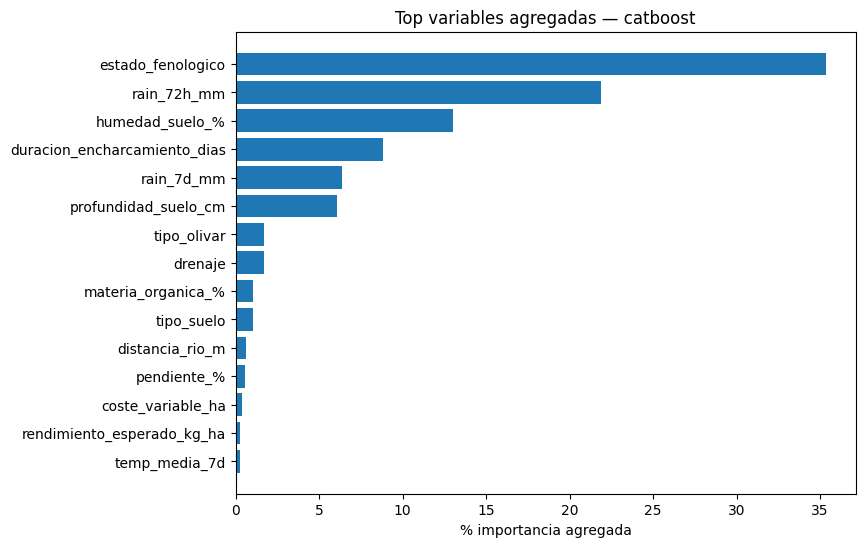

,categoria,importance_pct
1,neutra,61.075090
0,contextual,35.586823
2,prioritaria,3.338087



### xgboost


,variable_original,importance,importance_pct
5,estado_fenologico,0.638267,63.826721
11,rain_72h_mm,0.077333,7.733307
4,duracion_encharcamiento_dias,0.047986,4.798604
17,tipo_olivar,0.042965,4.296546
6,humedad_suelo_%,0.034086,3.408616
3,drenaje,0.033700,3.370027
10,profundidad_suelo_cm,0.026355,2.635529
18,tipo_suelo,0.025208,2.520789
20,zona_provincia,0.016585,1.658545
12,rain_7d_mm,0.013081,1.308122


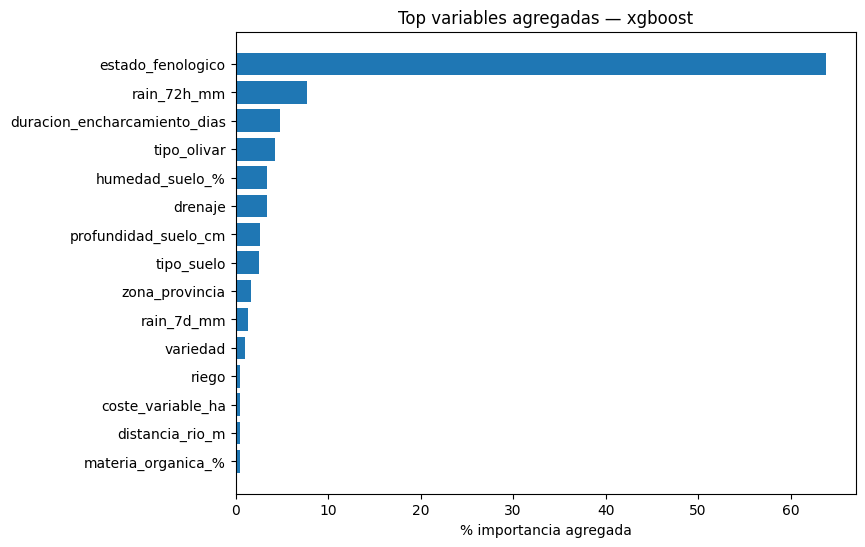

,categoria,importance_pct
0,contextual,66.513939
1,neutra,25.987726
2,prioritaria,7.498337



### lightgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000504 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 43
[LightGBM] [Info] Start training from score 0.044381
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

,variable_original,importance,importance_pct
11,rain_72h_mm,772,13.970322
4,duracion_encharcamiento_dias,648,11.726384
5,estado_fenologico,631,11.418748
6,humedad_suelo_%,487,8.812885
10,profundidad_suelo_cm,475,8.595729
12,rain_7d_mm,349,6.315599
7,materia_organica_%,285,5.157438
8,pendiente_%,233,4.216431
18,tipo_suelo,214,3.872602
2,distancia_rio_m,202,3.655447


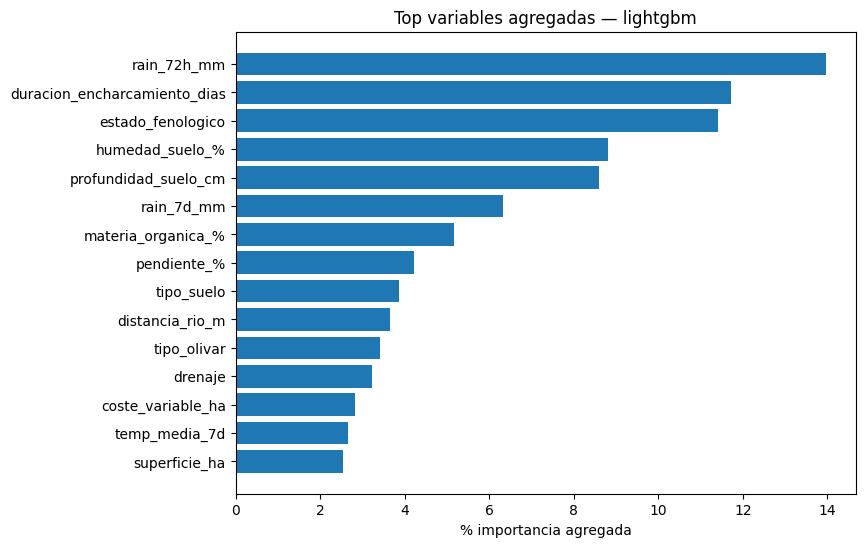

,categoria,importance_pct
1,neutra,73.814694
0,contextual,13.282664
2,prioritaria,12.902642


In [10]:
for nombre in results_df['modelo']:
    print(f'\n### {nombre}')
    best_pipeline = searches[nombre].best_estimator_
    best_pipeline.fit(X_model, y)
    fitted_preprocessor = best_pipeline.named_steps['preprocessor']
    fitted_model = best_pipeline.named_steps['model']
    feature_names = extraer_feature_names(fitted_preprocessor, numeric_features, categorical_features)
    importances = fitted_model.feature_importances_
    agg_df = agregar_importancias_por_variable(feature_names, importances, base_cols)
    display(agg_df.head(15))
    plot_top_variables(agg_df, f'Top variables agregadas — {nombre}', top_n=15)
    display(resumenes_categoria[nombre])


## 10. Selección final y predicción

In [11]:
best_model_name = results_df.iloc[0]['modelo']
best_pipeline = searches[best_model_name].best_estimator_
best_pipeline.fit(X_model, y)

validation_pred = np.clip(best_pipeline.predict(X_validation_model), 0, 1)
results = validation.copy()
results['pct_perdida_pred'] = validation_pred
results['impacto_eur_ha'] = results['rendimiento_esperado_kg_ha'] * results['pct_perdida_pred'] * results['precio_mercado_eur_kg']
results['impacto_total_parcela_eur'] = results['impacto_eur_ha'] * results['superficie_ha']
results.to_csv(OUTPUT_PATH, index=False)

print('Modelo seleccionado:', best_model_name)
print('Archivo guardado en:', OUTPUT_PATH)
display(results[[ID_COL, 'pct_perdida_pred', 'impacto_eur_ha', 'impacto_total_parcela_eur']])


Modelo seleccionado: catboost
Archivo guardado en: predicciones_modelo_interpretable.csv


,parcel_id,pct_perdida_pred,impacto_eur_ha,impacto_total_parcela_eur
0,TEST_01,0.000632,2.592217,32.402710
1,TEST_02,0.000000,0.000000,0.000000
2,TEST_03,0.000326,1.366928,13.122509
3,TEST_04,0.135351,1039.498748,21309.724329
4,TEST_05,0.223363,1711.299064,41413.437358
5,TEST_06,0.196352,869.448195,11998.385093
6,TEST_07,0.284870,2707.407431,78514.815499
7,TEST_08,0.356789,1535.974862,21810.843044
8,TEST_09,0.287992,1089.471893,12528.926765
9,TEST_10,0.463646,3578.883467,81598.543037
